# 第５章　定常性

宇都宮大学　吉田勝俊

2026.3.17
初版2026.1.6

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

グラフの線種等の一括設定

In [ ]:
from matplotlib import rcParams
rcParams['lines.linewidth']=0.3
rcParams['lines.markersize']=1.2

テキストセルで使う LaTeX マクロ

- $\newcommand{\ave}[1]{\big\langle#1\big\rangle} \ave{x}$
$\newcommand{\bm}[1]{\boldsymbol{#1}} \bm{x}$

In [ ]:
def graph_paper(lab1):
    """グラフ用紙の作成"""
    fig, ax = plt.subplots(1,1, figsize=(6.4, 2.4))
    ax.set_xlabel(r'time $i$')
    ax.set_ylabel(lab1)
    ax.grid();

    return fig, ax

## ■ 定常性とは？

物理学でいう**定常 (stationary)** とは，状態が一定で変化しないことです．

確率過程の標本路は，常にランダムに変動しているので，標本路単独では定常とはいえません．

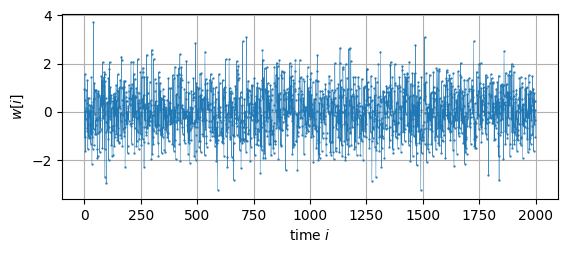

In [ ]:
# 標準ガウス白色過程の例

x_w = np.random.normal(size=2000)
fig, ax = graph_paper(lab1=r'$w[i]$')
ax.plot(x_w, '.-')

しかしながら，ばらつき方については，似た感じが続いているように見えませんか？

確率論では，このような恒常的なばらつき方を，個別の標本路ではなく，<br/>それらを束ねた確率過程の性質として特徴づけます．２種類あります．

1. **弱定常 (weak stationary)：**<br/>多数の標本路の平均と自己相関関数が時間変化しない．
2. **強定常 (strict stationary)：**<br/>多数の標本路の確率密度関数が時間変化しない．<br/>強定常なものは弱定常でもある（逆は成立しない）．

ただし，ここでいう平均，自己相関関数，確率密度関数は，**アンサンブル統計**の意味です．

> **３章の復習**
>
> 1. **時間統計 (time statistics)**：（略）
> 2. **アンサンブル統計 (ensemble statistics)**：<br/>時刻 $i=\bar i$ における確率変数 $x[\omega]:=x[\omega,\bar i]$ を取り出す．その全ての値<br/>$\qquad\{x[\omega_1],x[\omega_2],x[\omega_3],\cdots\}
:=
\{x[\omega_1,\bar i],x[\omega_2,\bar i],x[\omega_3,\bar i],\cdots\}
$<br/>を集計した統計のこと．

というわけで，定常性の議論にはアンサンブル統計が必要なので，導入していきます．

## ■ 確率過程のアンサンブル統計

時間統計は，単独の標本路から求めましたが，
<br/>アンサンブル統計は，確率過程（複数の標本路の束）から求めます．

### ● 概要

最初に，アンサンブル統計の概要を具体例で示しておきます．

確率過程 $x[\omega,i]$ とは，標本点（識別子）$\omega$ と時刻 $i$ の２変数関数のことでした．
<br/>同じ確率過程からサンプリングされた複数の標本路を以下に示します．

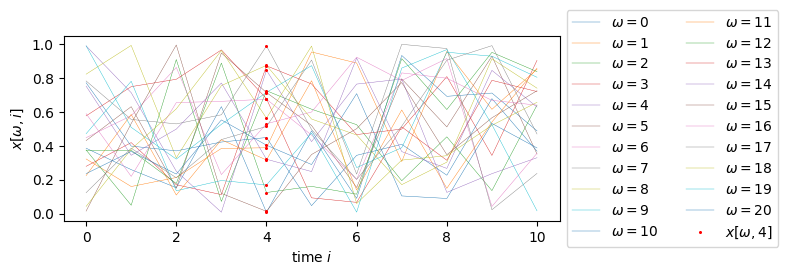

In [ ]:
### 確率過程の例（一様乱数，Numpy配列による実装） ###

Nsample = 21    #標本数
length  = 11    #標本路長

# 確率過程（と同じ構造のデータ）
x = np.array([np.random.uniform(size=length) for i in range(Nsample)])
time = list(range(length)) #時間軸

# 確率過程に含まれる標本路のプロット
fig, ax = plt.subplots(1,1,figsize=(6.4,2.4))
for omega in range(Nsample):
    ax.plot(time, x[omega,:], label=r'$\omega=$'+f'{omega}')

# 例えば x[omega, i=4] の抽出
x4 = x[:,4]
ax.plot(4*np.ones(Nsample), x4, 'ro', label=r'$x[\omega,4]$')

# 座標軸ほか
ax.set_xlabel(r'time $i$')
ax.set_ylabel(r'$x[\omega,i]$')
ax.legend(ncol=2, loc="center left", bbox_to_anchor=(1, 0.5))

各色の折れ線は，各標本点 $\omega=0,1,\cdots,20$ に割り当てられた標本路を表します．

赤点は，時刻 $i=4$ における確率変数 $x[\omega,4]$ から抽出した標本（**スライス**ともいう）です．





> **２章の復習（サイコロ投げ）**
> |標本空間|母集団|標本|
> |:--|:--|:--|
> |Ω = {1, 2, 3, 4, 5, 6}|U = {2, 1, 3, 6, 6, 1, 4, 1, 2, 4, 4, 5, 4, 6, 4, 4, 2, 5, 1, 5, ...}|Π = {6, 2, 4, 1, 2, 4, 3, 5}|
> |試行結果の種類|試行結果の全体|試行結果の一部（母集団の部分集合）|
>
> ※本章の例では，試行結果は数値ではなく，標本路（時系列）です．

この標本（赤点達）を書き出すと，次のようになります．

In [ ]:
print(x4)

[0.00824059 0.38911623 0.72559979 0.87242044 0.84605349 0.71503876
 0.53091294 0.5149177  0.87539869 0.71571669 0.44954868 0.31696023
 0.12500631 0.67840953 0.32146108 0.01408    0.6756007  0.98971049
 0.56384498 0.16982201 0.40442656]


この赤点達の平均や分散などが，時刻 $i=4$ のアンサンブル統計となります．
<br/>例えば，アンサンブル平均は，次のように求まります．

In [ ]:
print(np.mean(x4))

0.5191564713135048


他の時刻でも，同様にアンサンブル統計していくと，時刻 $i$ ごとの平均（や分散など）が求まります．

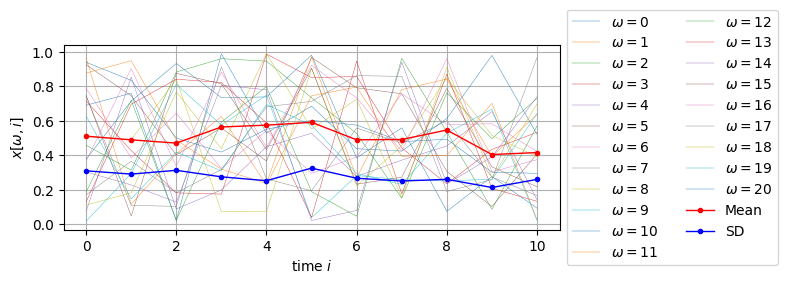

In [ ]:
### アンサンブル平均と標準偏差の例（一様乱数，Numpy配列による実装） ###

Nsample = 21    #標本数
length  = 11    #標本路長

# 確率過程（と同じ構造のデータ）
x = np.array([np.random.uniform(size=length) for i in range(Nsample)])
time = list(range(length)) #時間軸

# 確率過程に含まれる標本路のプロット
fig, ax = plt.subplots(1,1,figsize=(6.4,2.4))
for omega in range(Nsample):
    ax.plot(time, x[omega,:], label=r'$\omega=$'+f'{omega}')

# 各時刻の平均
mean = np.zeros(length) #各時刻ごとの平均をストアする空の配列
sd   = np.zeros(length) #各時刻ごとの標準偏差をストアする空の配列
for i in range(length):
    xi = x[:,i]             #現在時刻の確率変数の標本（赤点）
    mean[i] = np.mean(xi)   #現在時刻の平均
    sd[i]   = np.std(xi)    #現在時刻の標準偏差

ax.plot(time, mean, 'ro-', lw=1, ms=3, label=r'Mean')
ax.plot(time, sd, 'bo-', lw=1, ms=3, label=r'SD')

# 座標軸ほか
ax.set_xlabel(r'time $i$')
ax.set_ylabel(r'$x[\omega,i]$')
ax.legend(ncol=2, loc="center left", bbox_to_anchor=(1, 0.5))
ax.grid()

太い赤線が，各 $i$ 上のアンサンブル平均 (Mean)，青線が標準偏差 (SD) です．
このように，
- 確率過程のアンサンブル統計は，標本路と同じ時間軸上の，時間の関数になる！

> ### 演習１
>
> 標本数 `Nsample` を増やすと，次のコードのアンサンブル平均は，一定値に近づく．
> <br/>以下のセルで実行して確認せよ．
>
> ```python
> Nsample = 21    #標本数　←ここを変更する
> length  = 11    #標本路長
>
> x = np.array([np.random.uniform(size=length) for i in range(Nsample)])
> time = list(range(length)) #時間軸
>
> fig, ax = plt.subplots(1,1,figsize=(6.4,2.4))
> #標本路が多くて邪魔なときは，次の2行をコメントアウトする
> for omega in range(Nsample):
>     ax.plot(time, x[omega,:], label=r'$\omega=$'+f'{omega}')
>
> mean = np.zeros(length) #各時刻ごとの平均をストアする空の配列
> std  = np.zeros(length) #各時刻ごとの標準偏差をストアする空の配列
> for i in range(length):
>     xi = x[:,i]             #現在時刻の確率変数の標本（赤点）
>     mean[i] = np.mean(xi)   #現在時刻の平均
>     sd[i] = np.std(xi)      #現在時刻の標準偏差
>
> ax.plot(time, mean, 'ro-', lw=1, ms=3, label=r'Mean')
> ax.plot(time, sd, 'bo-', lw=1, ms=3, label=r'SD')
> ax.set_xlabel(r'time $i$')
> ax.set_ylabel(r'$x[\omega,i]$')
> ```


以上を念頭に，代表的なアンサンブル統計を導入していきます．

### ● アンサンブル統計

確率過程 $x[\omega,i]$ から，標本数 $N$ の標本 $\Pi_N$ を抽出します．

$\Pi_N=\{\omega_1,\omega_2,\cdots,\omega_N\}$

> **標本 $\Pi_N$ の採り方：**
>
> 標本 $\Pi_N$ に標本路（時系列）を直接収めるのは愚策（複雑怪奇）なので，<br/>
> 標本 $\Pi_N$ には，識別子 $\omega_1,\omega_2,\cdots,\omega_N$ だけ収める方式をとります．（数学の流儀）

時間統計では，時刻 $i$ をスキャンして集計しましたが，
以下のアンサンブル統計では，標本点 $\omega$ をスキャンします．

※集計の軸が違うだけで，やることは同じ．足して総数で割る．

#### **》平均 (mean)：**

次式を，（時刻 $i$ における）**平均 (mean/average)** と呼びます．

$$
m_x[i]
:=
\ave{x[i]}
:=
\frac{1}{N}\sum_{\omega \in \Pi_N} x[\omega,i]
$$

> **集合上の総和：**
> $S = X[\omega_1] + X[\omega_2] + \cdots + X[\omega_N]$ のことを，次のように表記します．
>
> $\quad\displaystyle S = \sum_{\omega\in A}X[\omega],\qquad A:=\{\omega_1,\omega_2,\cdots,\omega_N\}$

#### **》平均操作 $\ave{\cdot}$ の公式：**

定数 $a$ と確率過程 $x[\omega,i]$, $y[\omega,i]$について，時間統計と同形の公式が成立します．

- $\ave{a}= a$
- $\ave{a x[i]}= a\ave{x[i]}$
- $\ave{x[i] + y[i]}=\ave{x[i]}+\ave{y[i]}$

> 証明） $\ave{a x[i]} := \frac{1}{N}\sum_{\omega\in\Pi_N} ax[\omega,i] = a\frac{1}{N}\sum_{\omega\in\Pi_N} x[\omega,i]  = a\ave{x[i]}$ ※他も同様
>
> 計算例） $\ave{(x[i] - m_x[i])^2} = \ave{x[i]^2 - 2x[i]m_x[i]+ m_x[i]^2} = \ave{x^2[i]} - 2m_x[i]\ave{x[i]}+ m_x[i]^2 = \ave{x^2[i]} - m_x[i]^2$

時間統計との違いとして，各項が時刻 $i$ に依存しています．

#### **》積率 (moment)：**

時間統計と同様に，$n$乗の平均を，（時刻 $i$ における）**$n$次モーメント (moment)** といいます．モーメントを**積率**ともいいます．

$$
m_x^{(n)}[i]
:=
\ave{x[i]^n}
:=
\frac{1}{N}\sum_{\omega \in \Pi_N} x[\omega,i]^n
$$

同様に，平均値からの変動の積率を，**中心 $n$ 次モーメント ($n$th central moment)** といいます．

$$
\sigma_x^{(n)}[i]
:=
\ave{(x[i]-m_x[i])^n}
:=
\frac{1}{N}\sum_{\omega \in \Pi_N} (x[\omega,i] - m_x[i])^n
$$

#### **》分散 (variance)**：

**中心 $2$ 次モーメント (2nd central moment)** を，（時刻 $i$ における）**分散 (variance)** と呼び，分布の広がりの程度を表します．

$$
\sigma_x^2[i]
:=
\sigma^{(2)}_x[i]
:=
\frac{1}{N}\sum_{\omega\in\Pi_N} (x[i]-m_x[i])^2
$$

分散の正の平方根 $\sigma_x[i]:=\sqrt{\sigma_x[i]^2}$ を，（時刻 $i$ における）**標準偏差 (standard deviation, SD)** といいます．



#### **》共分散 (covariance)：**

２種類の確率過程 $x[\omega,i]$, $y[\omega,i]$ に対して，次式を（時刻 $i$ における）**共分散 (covariance)** といいます．

$$
\sigma_{xy}[i]
:=
\langle (x[i]-m_x[i])(y[i]-m_y[i])\rangle
:=
\frac{1}{N}\sum_{\omega\in\Pi_N} (x[\omega,i]-m_x[i])(y[\omega,i]-m_y[i])
$$

#### **》相関係数 (correlation coefficient)：**

正規化した共分散（標準偏差で割った）を，（時刻 $i$ における）**相関係数 (correlation coefficient)** といいます．

$$
\rho_{xy}[i]
:=
\left\langle \frac{(x[i]-m_x[i])}{\sigma_x[i]}\frac{(y[i]-m_y[i])}{\sigma_y[i]}\right\rangle
=
\frac{\sigma_{xy}[i]}{\sigma_x[i]\sigma_y[i]}
$$

#### **》自己共分散関数 (autocovariance function, ACVF)：**

第３章の時間統計では，単独の標本路を時間方向に集計し，その標本路の自己共分散関数を求めました．この集計によって，時刻 $i$ は消えてしまうので，時間統計の自己共分散関数は，ラグ $k$ のみの関数になりました．

これに対して，アンサンブル統計では，時刻 $i$ とラグ $k$ の両方の関数になります．

$$
C_{xx}[i,k]
:=
\frac{1}{N}\sum_{\omega\in\Pi_N}(x[\omega,i]-m_x[i])(x[\omega,i+k]-m_x[i])
$$


これにより，自分自身との類似度の時間変化（時刻 $i$ における類似度）を表すことができます．

#### **》自己相関関数 (autocorrelation function, ACF)：**

自己共分散関数を分散（標準偏差の２乗 $\sigma_x[i]^2=\sigma_x^2[i]$）で正規化したものです．

$$
R_{xx}[i,k]
:=
\frac{C_{xx}[i,k]}{\sigma^2_x[i]}
=
\frac{C_{xx}[i,k]}{C_{xx}[i,0]}
$$

### ● 実装

In [ ]:
def ensemble_stat(path_func, Nsample, length):
    """
    平均，標準偏差，自己相関関数をまとめて推定する
    モンテカルロ・シミュレーション

    def path_func(length):
        '''標本路を生成するユーザ関数'''
        return 生成した標本路のリスト

    Nsample ... 標本数
    length .... 標本路長
    """

    ### ラグの最大値　時系列長の 1/4 にしておく
    max_lag = length//4

    ### 標本路の生成（自己相関関数のラグの分だけ延長）
    extended_length = length + max_lag
    extended_paths = np.array([path_func(extended_length) for i in range(Nsample)])
    #本来の長さ
    paths = extended_paths[:,:length]

    #時間軸とラグの軸
    time = list(range(length))
    lag = time[:max_lag] #ついでにラグの軸

    ### 平均値，標準偏差，自己相関関数
    mean = np.zeros(length)             #各時刻の平均をストアする空の配列
    sd   = np.zeros(length)             #同じく標準偏差
    acf  = np.zeros((length, max_lag))  #同じく自己相関関数

    for i in range(length):
        xi = extended_paths[:,i]    #現在時刻の確率変数の標本
        mean[i] = np.mean(xi)       #現在時刻の平均
        sd[i] = np.std(xi)          #現在時刻の標準偏差

        for k in range(max_lag):
            xik = extended_paths[:,i+k]             #未来時刻の確率変数の標本
            acf[i,k] = np.corrcoef(xi, xik)[0,1]    #現在時刻の自己相関係数
            #np.corrcoef は行列を返す．非対角要素が相関係数

    return (
        time,   #時間軸
        paths,  #標本路
        mean,   #平均
        sd,     #標準偏差
        lag,    #ラグの軸
        acf     #自己相関関数
    )

In [ ]:
def plot_ensemble_stat(result, show_path=False, show_sd=False, i0=1):
    """アンサンブル統計のプロット"""

    time, paths, mean, sd, lag, acf = result

    fig, ax = plt.subplots(2,1,figsize=(6.4,4.8))

    ### 標本路
    if show_path: #True なら見本路もプロットする
        for omega in range(len(paths)):
            ax[0].plot(time, paths[omega,:])

    ### 平均，標準偏差
    ax[0].plot(time, mean, 'r.-', label=r'Mean')
    if show_sd:
        ax[0].plot(time, sd, 'b.-', label=r'SD')
    ax[0].set_xlabel(r'time $i$')
    ax[0].set_ylabel(r'$x$')
    ax[0].legend(loc="center left", bbox_to_anchor=(1, 0.5))
    ax[0].grid()

    ### 自己相関関数
    # 異なる色が，異なる時刻 i を表す！
    tn = len(time)
    for i in range(tn):
        ax[1].plot(lag, acf[i,:], '-')

    # i0 番目と最後の時刻
    ax[1].plot(lag, acf[i0,:], 'b-', lw=1.0, label='$i=%d$'%(i0))
    ax[1].plot(lag, acf[tn-1,:], 'r-', lw=1.0, label='$i=%d$'%(tn-1))

    ax[1].set_xlabel(r'lag $k$')
    ax[1].set_ylabel(r'ACF')
    ax[1].text(
        1, 1,
        "*Different colors indicate different times $i$",
        ha="right", va="bottom", transform=ax[1].transAxes,
        fontsize=8
    )
    ax[1].grid()
    ax[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))

    fig.tight_layout()

    return fig, ax

#### **》動作確認**

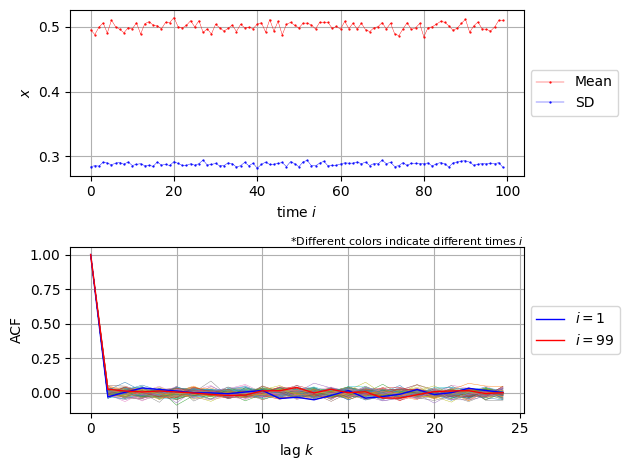

In [ ]:
def path_uniform(length):
    """一様分布の無相関過程の標本路"""
    return np.random.uniform(size=length)

result = ensemble_stat(path_uniform, Nsample=2000, length=100)
plot_ensemble_stat(result, show_sd=True);


ACF の異なる色は，異なる時刻 $i$ を表します．

### ● モンテカルロ・シミュレーション

演習１で見たように，標本数を増やすとアンサンブル統計は，収束に向かいます．
<br/>実は，この収束は，次の２つの定理によって数学的に保証されています．

> - **定理（大数の法則）**：
>   - アンサンブル統計は，標本数を増やすと，真値に収束する．
> - **定理（中心極限定理）**：
>   - アンサンブル統計のばらつきは，標本数を増やすと，分散 $0$ のガウス分布に収束する．
> - **意訳**：
>   - 標本数を増やすと，アンサンブル統計のばらつきは減少し，真値に近づく．

もちろん，有限の標本数で計算する限り，真値にはたどり着けないのですが，
<br/>標本数を十分に大きくすれば，妥当な近似値が得られるでしょう．

このような，膨大な標本路に基づく**近似計算法**を，一般に，
<br/>**モンテカルロ・シミュレーション (Monte Carlo simulation)** といいます．

すなわち，演習１では，
- モンテカルロ・シミュレーションにより，アンサンブル統計の**近似値**を計算した．

ということになります．あくまで近似であることにご注意ください．

> ### 演習２
>
> 1. 標準ガウス白色過程（第４章，平均0，分散1のガウス分布）のアンサンブル統計を求めよ．
> 2. 標本数 `Nsample`を増加させて，アンサンブル統計が収束に向かう様子を確認せよ．
>
> ※次のコードを以下のセルで実行せよ．
>
> ```python
> def path_gauss(length):
>     """標準ガウス白色過程の標本路"""
>     return np.random.normal(loc=0.0, scale=1.0, size=length) #平均0，分散1
>
> result = ensemble_stat(path_gauss, Nsample=200, length=100)
> plot_ensemble_stat(result, show_sd=True)
> ```


## ■ 弱定常性（平均と自己相関関数）

### ● 無相関過程

演習１と演習２の繰り返しになりますが，定常性の観点で改めて見てみます．
<br/>標本路長は第４章に合せて `length=1000` にしておきます．

**※計算に30秒弱かかると思います．待てない人は Nsample を小さくしてください．**

#### **》無相関過程 (uncorrelated process)**

(0.0, 0.5309244621618646)

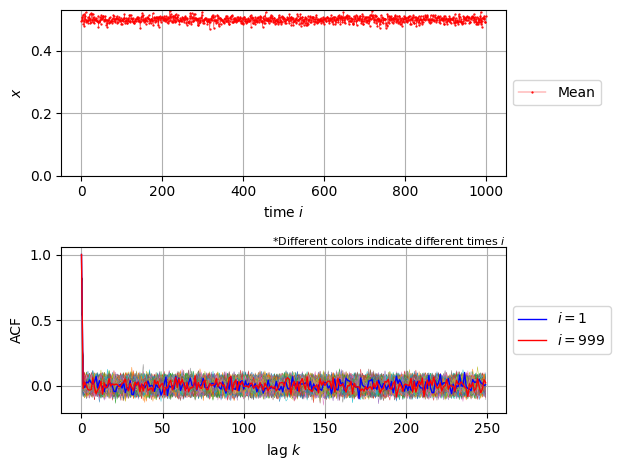

In [ ]:
def path_uniform(length):
    """一様分布の無相関過程の標本路"""
    return np.random.uniform(size=length)

result = ensemble_stat(path_uniform, Nsample=1000, length=1000)
fig, ax = plot_ensemble_stat(result)
ax[0].set_ylim(bottom=0)

標本数が有限なので，あくまで近似的に，ではありますが，
<br/>次の２条件を満たすので，無相関過程は**弱定常**です．

- 平均値 (Mean) が時間変化しない．
- 自己相関関数 (ACF) が時間変化しない．（異なる時刻の関数形が同じ）

#### **》 白色過程 (white process)**

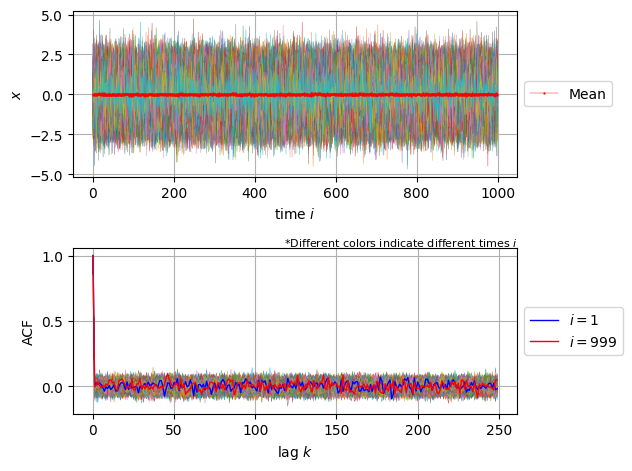

In [ ]:
def path_gauss(length):
    """標準ガウス白色過程の標本路"""
    return np.random.normal(loc=0.0, scale=1.0, size=length) #平均0，分散1

result = ensemble_stat(path_gauss, Nsample=1000, length=1000)
plot_ensemble_stat(result, show_path=True);

同じく，（標本数有限による誤差の範囲で）２条件を満たすので，白色過程は**弱定常**です．

1. 平均値 (Mean) が時間変化しない．
2. 自己相関関数 (ACF) が時間変化しない．（異なる時刻の関数形が同じ）



### ● 離散時間ブラウン運動 (discrete time Brownian motion) ※ガウス分布の酔歩

In [ ]:
def path_Brown(length):
    """離散時間ブラウン運動（ガウス分布の酔歩）の標本路"""
    w = np.random.normal(size=length)
    path = np.zeros(length)

    path[0] = 0 #初期値はゼロにする（ゼロでなくてもよいが）
    for i in range(1,length):
        path[i] = path[i-1] + w[i]

    return path

まず，標本数少な目で，標本路を観察してましょう．

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


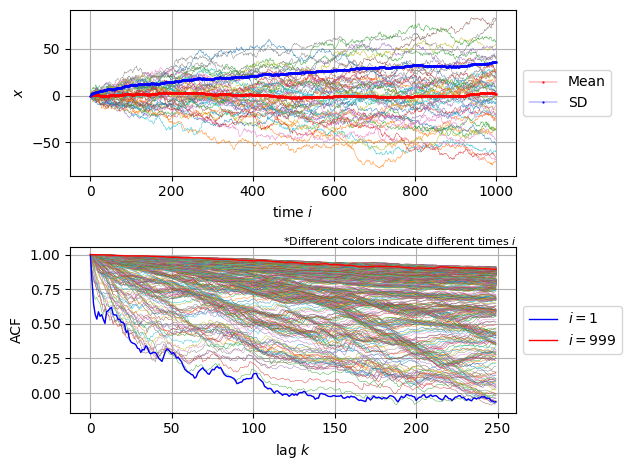

In [ ]:
result = ensemble_stat(path_Brown, Nsample=50, length=1000)
plot_ensemble_stat(result, show_path=True, show_sd=True);

このように，酔歩の標本路 $x$ は，原点 $x=0$ から周辺に拡散していきます．

さらに標本数を増加させて，アンサンブル統計の精度を上げてみます．

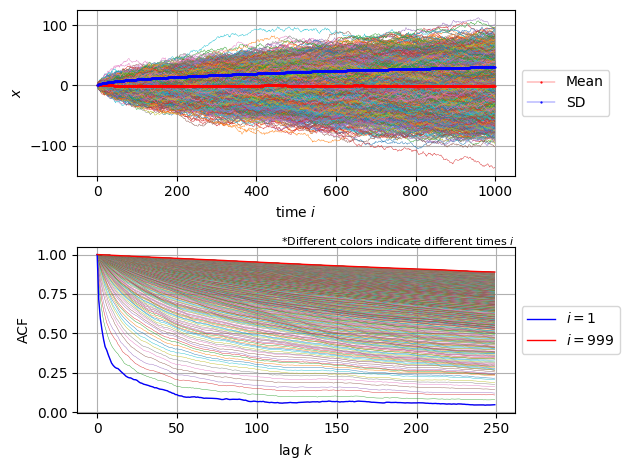

In [ ]:
Nsample=5000
result = ensemble_stat(path_Brown, Nsample=Nsample, length=1000)
plot_ensemble_stat(result, show_path=True, show_sd=True);

- 平均値 (Mean) は，標本路が拡散する範囲（$-100$～$100$ 程度）を基準にすると，相対的にはほぼ一定値．
- 自己相関関数 (ACF) は明らかに時間変化している．
  - 時間 $i$ の増大とともに，ACFの減衰が弱まる → 過去の影響が強まる．
    - それまでの経路から大きくは逸脱できないので，そうなります．
  - 一般に，ブラウン運動のACFは，十分に大きな $i$ に対して，ラグの１次関数になる．（詳細は専門書に譲る）

ゆえに，酔歩は，**弱定常ではありません**．

## ■ 強定常性（アンサンブル確率密度関数）

### ● 非定常過程のテストデータ

弱定常でも強非定常でもないことを，**非定常 (non-stationary)** といいます．
<br/>わざと非定常にした確率過程のテストデータを用意しておきます．

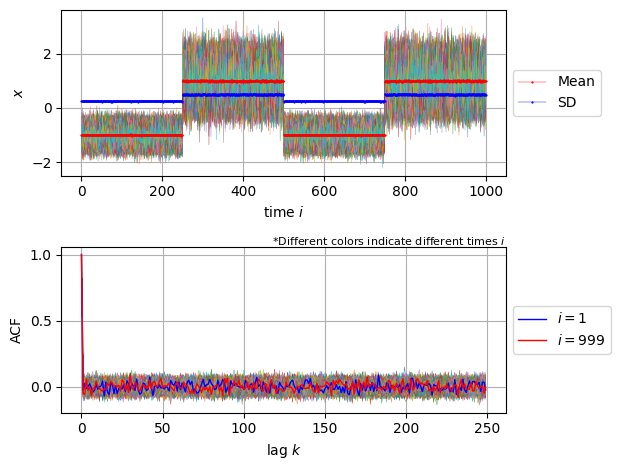

In [ ]:
def path_nonstat(length, sublength):
    """
    非定常過程の標本路
    sublength ごとに平均と標準偏差を交代させる
    """
    path = np.zeros(length)
    n = length//sublength

    for i in range(n):
        min_i = i*sublength
        max_i = min((i+1)*sublength, length)

        if i%2 == 0:    #偶数区間
            loc = -1        #平均
            scale = 1/4     #標準偏差
        elif i%2 == 1:  #奇数区間
            loc = 1         #平均
            scale = 1/2     #標準偏差

        path[min_i:max_i] = np.random.normal(
            loc=loc,
            scale=scale,
            size=max_i-min_i
        )

    return path

result_nonstat = ensemble_stat(
    lambda l: path_nonstat(l, sublength=250),
    Nsample=1000, length=1000
)
fig, ax = plot_ensemble_stat(result_nonstat, show_sd=True, show_path=True)

- 平均 (Mean) と標準偏差 (SD) が途中で切り替わるので，弱定常ではありません．
- ただし，切り替えの前後とも等しく白色過程ではあるので，自己相関関数 (ACF) は変化しません．

### ● 単独の標本路の（時間統計的な）確率密度関数

まず，テストデータに含まれる値を全て集めて，それを標本とする確率密度関数を求めてみます．
<br/>実験データの確率密度関数は，暗黙にこのタイプであることが多いと思います．

Text(0, 0.5, '$p(x)$')

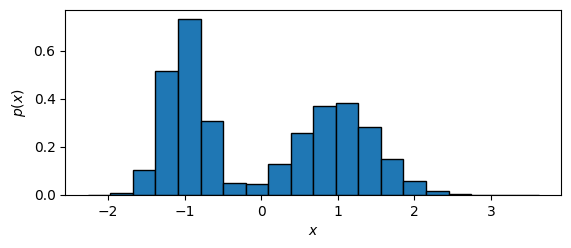

In [ ]:
testdat_nonstat = path_nonstat(length=5000000, sublength=250)

fig, ax = plt.subplots(1,1, figsize=(6.4, 2.4))
ax.hist(testdat_nonstat, bins=20, histtype="bar", edgecolor='black', density=True)
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x)$')

２種類の確率密度関数（左：平均-1 標準偏差1/4）（右：平均1 標準偏差1/2）を重ね合わせたものが得られます．

#### **》時間統計的な確率密度関数の欠点**

このような標本路単独の確率密度関数には，欠点があります．
<br/>性質の異なる標本路であっても，出現する値の頻度が同じだと，確率密度関数は同じになってしまいます．

具体例で見てみましょう．２つ目のテストデータを用意します．切り替えまでの持続時間を変えてみます．


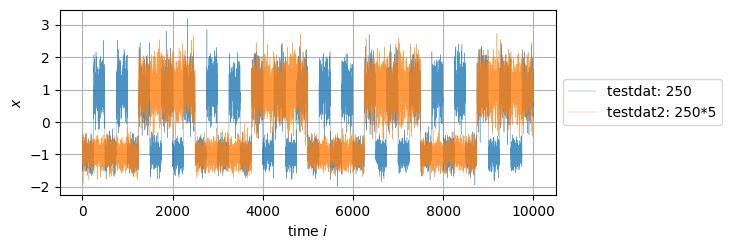

In [ ]:
#テストデータ２：切り替えまでの時間を拡大
testdat2_nonstat = path_nonstat(length=5000000, sublength=250*5)

fig, ax = graph_paper(lab1=r'$x$')

ax.plot(testdat_nonstat[:10000], label="testdat: 250", alpha=0.8)
ax.plot(testdat2_nonstat[:10000], label="testdat2: 250*5", alpha=0.8)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

標本路の性質が大きく変化しました．前者(testdat)は切り替えが激しく，後者(testdat2)はゆっくりです．
<br/>しかし，この大きな違いは，確率密度関数には表れません．標本数有限による誤差を除けば，同じ分布形です．

Text(0, 0.5, '$p(x)$')

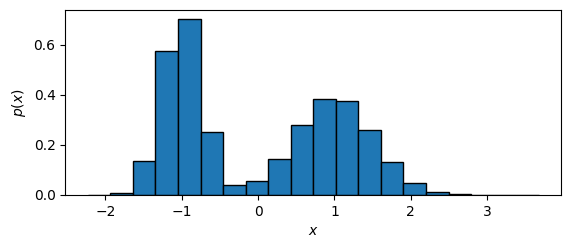

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6.4, 2.4))
ax.hist(testdat2_nonstat, bins=20, histtype="bar", edgecolor='black', density=True)
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x)$')

### ● アンサンブル確率密度関数 (ensemble probability density function)

そこで，アンサンブル統計と同じ発想を，確率密度関数にも導入します．
<br/>これを，**アンサンブル確率密度関数 (ensemble probability density function)** といいます．
<br/>標本路の束（確率過程）を考え，各時刻ごとの確率密度関数を求めたものです．

アンサンブル確率密度関数は，時刻ごとに求まるので，分布の軸 $x$ と時刻 $i$ の２変数関数 $p(x,i)$ になります．
<br/>そのうえで，時間変化するもの，しないものを区別します．

- 分布形が時間変化する確率密度関数を，**非定常確率密度関数 (non-stationary probability density function)**，または**時変確率密度関数 (Time-varying probability density function)** という．
- 時間変化しない確率密度関数を，**定常確率密度関数 (stationary probability density function)** という．


この用語を使うと，**強定常**を簡潔に定義できます．すなわち，
- ある確率過程が**強定常**であるとは，そのアンサンブル確率密度関数が，定常確率密度関数になることである．

#### **》簡単な例（離散時間ブラウン運動）**

プログラミングは，演習１のアンサンブル平均とほとんど同じです．
<br/>最後に平均を計算するのか，確率密度関数を求めるのかの違いです．

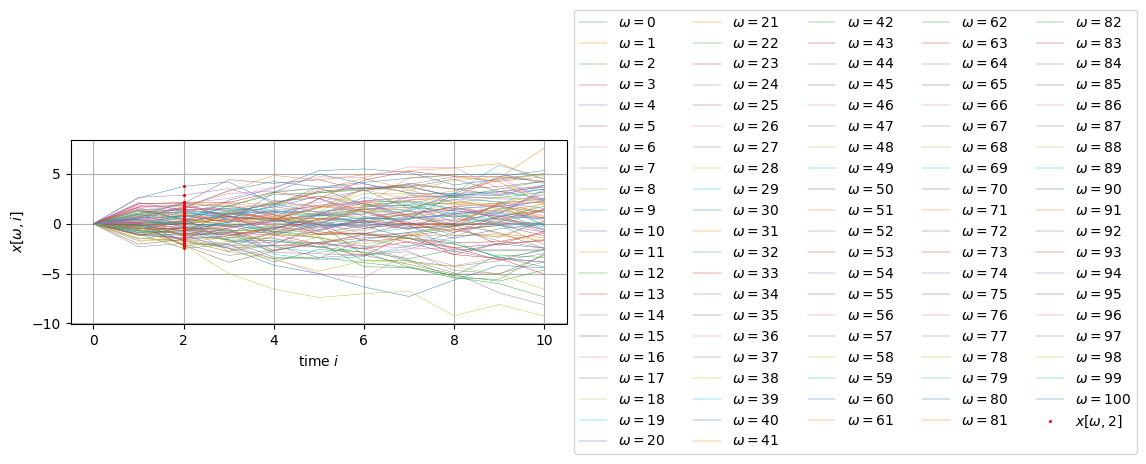

In [ ]:
### 離散時間ブラウン運動 ###

Nsample = 101    #標本数
length  = 11    #標本路長

# 確率過程（と同じ構造のデータ）
x_brown = np.array([path_Brown(length) for i in range(Nsample)])
time = list(range(length)) #時間軸

# 確率過程に含まれる標本路のプロット
fig, ax = plt.subplots(1,1,figsize=(6.4,2.4))
for omega in range(Nsample):
    ax.plot(time, x_brown[omega,:], label=r'$\omega=$'+f'{omega}')

# 例えば x[omega, i=2] の抽出
x2_brown = x_brown[:,2]
ax.plot(2*np.ones(Nsample), x2_brown, 'ro', label=r'$x[\omega,2]$')

# 座標軸ほか
ax.set_xlabel(r'time $i$')
ax.set_ylabel(r'$x[\omega,i]$')
ax.legend(ncol=5, loc="center left", bbox_to_anchor=(1, 0.5))
ax.grid()

赤点の確率密度関数が，時刻 $i=2$ におけるアンサンブル確率密度関数 $p(x,i)$ となります．

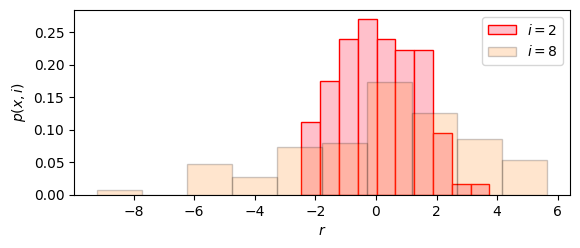

In [ ]:
### 離散時間ブラウン運動のアンサンブル確率密度関数(i=4)

fig, ax = plt.subplots(1,1,figsize=(6.4,2.4))
ax.hist(x2_brown, density=True, histtype="bar", edgecolor='red', facecolor='pink', label='$i=2$')
x8_brown = x_brown[:,8] #ついでに別時刻
ax.hist(x8_brown, density=True, histtype="bar", edgecolor='black', label='$i=8$', alpha=0.2)
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x,i)$')
ax.legend();

同様に，$i=8$ におけるアンサンブル確率密度関数もプロットしましたが，
<br/>分布形が時間変化しています．ゆえに，この例は非定常です．

#### **》実装**

標本路の束を求める処理に時間がかかるので，１回で済むよう，クラスで実装してみます．

In [ ]:
class ensemble_PDF:
    """
    アンサンブルPDFを推定する
    モンテカルロ・シミュレーション
    """

    def __init__(self, path_func, Nsample, length):
        """
        コンストラクタ

        def path_func(length):
            '''標本路を生成するユーザ関数'''
            return 生成した標本路のリスト

        Nsample ... 標本数
        length .... 標本路長
        """
        self.Nsample, self.length = Nsample, length

        ### 標本路の生成
        self.paths = np.array([path_func(length) for i in range(Nsample)])

    def pdf(self, i, bins=20):
        """
        アンサンブル確率密度関数
        i ...... 時刻
        bins ... 階級数
        """
        testdat_i = self.paths[:,i]
        density, edges = np.histogram(testdat_i, bins=bins, density=True)
        centers = (edges[1:] + edges[:-1])/2 #各階級の中点

        return density, edges, centers, bins


    def summary(self, n):
        """
        結果の概要
        n ... 抽出する確率密度関数の数
        """
        # 抽出する時刻（整数）
        times = [int(i) for i in np.linspace(0, self.length-1, n+1)]

        # プロット
        fig, ax = plt.subplots(1,1,figsize=(6.4,2.4))

        for i in times[1:]:
            density, edges, centers, bins = self.pdf(i)
            ax.plot(centers, density, label=f"{i=}")

        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
        ax.grid()
        ax.set_xlabel('$x$')
        ax.set_ylabel('$p(x,i)$')

#### **》動作確認**

離散時間ブラウン運動のアンサンブル確率密度関数です．


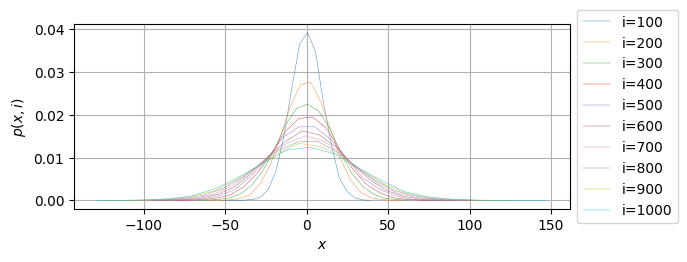

In [ ]:
pdf_Brown = ensemble_PDF(path_Brown, Nsample=50000, length=1001)
pdf_Brown.summary(10) #結果の概要

ブラウン運動（酔歩）特有の，時々刻々と拡散を強める性質（ピークが落ちて，裾野が広がる）が捉えられました．

> ### 演習３
>
> 非定常なテストデータのアンサンブル確率密度関数を求めよ．
> <br/>異なる分布が，混ざらずに判明する．
> <br/>※次のコードを，以下のセルで実行せよ．
>
> ```python
> pdf_nonstat = ensemble_PDF(
>    lambda l: path_nonstat(l, sublength=250),
>    Nsample=50000, length=1000
> )
> pdf_nonstat.summary(10) #結果の概要
> ```


## **■ 定常性の判別**

以上に述べた **■弱定常性** と **■強定常性** を組み合せると，定常性の判別が完結します．

### ● 実装

両者を集約したクラスを作っておきます．

In [ ]:
class Stationary:
    """
    平均，自己相関関数，アンサンブル確率密度関数を求める
    モンテカルロ・シミュレーション
    """

    def __init__(self, path_func, Nsample, length):
        """
        コンストラクタ

        def path_func(length):
            '''標本路を生成するユーザ関数'''
            return 生成した標本路のリスト

        Nsample ... 標本数
        length .... 標本路長
        """
        self.path_func = path_func
        self.Nsample, self.length = Nsample, length

        ### ラグの最大値　時系列長の 1/4 にしておく
        self.max_lag = self.length//4

        #時間軸とラグの軸
        self.time = np.array(list(range(self.length)))
        self.lag = self.time[:self.max_lag] #ついでにラグの軸

        ### 標本路の生成（自己相関関数のラグの分だけ延長）
        self.extended_length = self.length + self.max_lag
        self.extended_paths = np.array([
            self.path_func(self.extended_length)
            for i in range(self.Nsample)
        ])
        #本来の長さ
        self.paths = self.extended_paths[:,:length]

        ### アンサンブル統計の計算
        self.stat()


    ###
    ### 計算
    ###
    def stat(self):
        """
        平均，標準偏差，自己相関関数をまとめて推定する
        モンテカルロ・シミュレーション
        """
        ### 平均値，標準偏差，自己相関関数
        self.mean = np.zeros(self.length)   #各時刻の平均をストアする空の配列
        self.sd   = np.zeros(self.length)   #同じく標準偏差
        self.acf  = np.zeros((self.length, self.max_lag))  #同じく自己相関関数

        for i in range(self.length):
            xi = self.extended_paths[:,i]    #現在時刻の確率変数の標本
            self.mean[i] = np.mean(xi)       #現在時刻の平均
            self.sd[i] = np.std(xi)          #現在時刻の標準偏差

            for k in range(self.max_lag):
                xik = self.extended_paths[:,i+k]             #未来時刻の確率変数の標本
                self.acf[i,k] = np.corrcoef(xi, xik)[0,1]    #現在時刻の自己相関係数
                #np.corrcoef は行列を返す．非対角要素が相関係数

        return

    def pdf(self, i, bins=20):
        """
        アンサンブル確率密度関数
        i ...... 時刻
        bins ... 階級数
        """
        testdat_i = self.paths[:,i]
        density, edges = np.histogram(testdat_i, bins=bins, density=True)
        centers = (edges[1:] + edges[:-1])/2 #各階級の中点

        return density, edges, centers, bins

    ###
    ### プロット
    ###
    def summary(self, npath=1000, npdf=10, show_path=200, show_sd=False, i0=1):
        """
        結果の概要
        """
        self.plot_stat(show_path, show_sd, i0)
        self.plot_pdf(npdf)

    def plot_stat(self, show_path=False, show_sd=False, i0=1):
        """アンサンブル統計のプロット"""

        fig, ax = plt.subplots(2,1, figsize=(6.4, 4.8))

        ### 標本路
        if show_path is not False: #見本路もプロットする
            # Nsample > show_path なら間引く
            if Nsample > show_path:
                _step = self.Nsample//show_path
            else:
                _step = 1
            for omega in range(0, self.Nsample, _step):
                ax[0].plot(self.time, self.paths[omega,:])

        ### 平均，標準偏差
        ax[0].plot(self.time, self.mean, 'r.-', label=r'Mean')
        if show_sd:
            ax[0].plot(self.time, self.sd, 'b.-', label=r'SD')
        ax[0].set_xlabel(r'time $i$')
        ax[0].set_ylabel(r'$x$')
        ax[0].legend(loc="center left", bbox_to_anchor=(1, 0.5))
        ax[0].grid()

        ### 自己相関関数
        # 異なる色が，異なる時刻 i を表す！
        tn = len(self.time)
        for i in range(tn):
            ax[1].plot(self.lag, self.acf[i,:], '-')

        # i0 番目と最後の時刻
        ax[1].plot(self.lag, self.acf[i0,:], 'b-', lw=1.0, label='$i=%d$'%(i0))
        ax[1].plot(self.lag, self.acf[tn-1,:], 'r-', lw=1.0, label='$i=%d$'%(tn-1))

        ax[1].set_xlabel(r'lag $k$')
        ax[1].set_ylabel(r'ACF')
        ax[1].text(
            1, 1,
            "*Different colors indicate different times $i$",
            ha="right", va="bottom", transform=ax[1].transAxes,
            fontsize=8
        )
        ax[1].grid()
        ax[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))

        fig.tight_layout()

        return fig, ax

    def plot_pdf(self, npdf):
        """
        アンサンブル確率密度関数のプロット
        npdf ... 抽出する確率密度関数の数
        """
        times = [int(i) for i in np.linspace(0, self.length-1, npdf+1)]

        # プロット
        fig, ax = plt.subplots(1,1,figsize=(6.4,2.4))

        for i in times[1:]:
            density, edges, centers, bins = self.pdf(i)
            ax.plot(centers, density, label=f"{i=}")

        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
        ax.grid()
        ax.set_xlabel('$x$')
        ax.set_ylabel('$p(x,i)$')

        fig.tight_layout()

        return fig, ax

### ● 数値例

> ### 演習４
>
> 離散時間ブラウン運動の定常性を判別せよ．
> <br/>※次のコードを，以下のセルで実行せよ．
>
> ```python
> stat_Brown = Stationary(path_Brown, Nsample=50000, length=1001)
> stat_Brown.summary(10) #結果の概要
> ```


※3～4分かかりました

**判別結果**：
1. 平均 (Mean) と自己相関関数 (ACF) が時間変化しているので，弱定常ではない．
2. アンサンブル確率密度関数 $p(x,i)$ が時間変化しているので，強定常ではない．

ゆえに，いずれの基準から見ても，この確率過程は非定常である．